# Practical Statistics for Data Scientists (Python)
# Chapter 3. Statistial Experiments and Significance Testing
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck

# Chapter 3: Statistical Experiments and Significance Testing (Summary)

## Overview & Objective
Design of experiments lies at the core of empirical scientific decision-making and business optimization (e.g., A/B testing in web applications)[cite: 107, 108]. This chapter covers statistical inference methodologies designed to determine whether observed differences between treatments are genuine effects or mere products of random chance[cite: 107, 113, 114].

## Key Concepts
1. **A/B Testing:** Controlled randomized comparative trials testing an experimental treatment against a control baseline[cite: 108, 109].
2. **Hypothesis Testing:** Formulating the Null Hypothesis ($H_0$, no treatment difference) versus an Alternative Hypothesis ($H_1$) to safeguard against misinterpreting random noise as meaningful signal[cite: 113, 114, 115].
3. **Resampling & Permutation Tests:** Shuffling combined experimental groups to empirically recreate the null distribution without relying on parametric distribution assumptions[cite: 117, 122].
4. **Statistical Significance & p-Values:** Quantifying how likely results as extreme as the observed outcome could arise under the null model[cite: 123, 126]. Balancing Type 1 errors (false positives) and Type 2 errors (false negatives)[cite: 123, 129].
5. **ANOVA (Analysis of Variance):** Omnibus hypothesis testing comparing multiple group means simultaneously while mitigating alpha inflation[cite: 132, 138, 142].
6. **Chi-Square Test:** Testing goodness-of-fit and independence in categorical contingency tables[cite: 143, 147].
7. **Multi-Arm Bandits:** Adaptive testing frameworks that sequentially shift traffic toward the optimal treatment, balancing exploration and exploitation[cite: 151, 153, 154].

In [1]:
!pip install wquantiles dmba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 58.4 MB/s eta 0:00:00


In [2]:
# Clone repositori resmi dan pindahkan folder data langsung ke /content/data
!git clone https://github.com/gedeck/practical-statistics-for-data-scientists.git temp_repo
!cp -r temp_repo/data /content/data
!rm -rf temp_repo

Cloning into 'temp_repo'...
remote: Enumerating objects: 621, done.
remote: Counting objects: 100% (241/241), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 621 (delta 182), reused 150 (delta 144), pack-reused 380 (from 3)
Receiving objects: 100% (621/621), 95.32 MiB | 18.44 MiB/s, done.
Resolving deltas: 100% (302/302), done.


Import required Python packages.

In [3]:
%matplotlib inline

from pathlib import Path
import random

import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats import power

import matplotlib.pylab as plt

In [4]:
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

Define paths to data sets. If you don't keep your data in the same directory as the code, adapt the path names.

In [5]:
WEB_PAGE_DATA_CSV = DATA / 'web_page_data.csv'
FOUR_SESSIONS_CSV = DATA / 'four_sessions.csv'
CLICK_RATE_CSV = DATA / 'click_rates.csv'
IMANISHI_CSV = DATA / 'imanishi_data.csv'

# Resampling

## Theoretical Deep-Dive: A/B Testing & Permutation Tests

### 1. The Logic of A/B Testing
In a classical A/B experiment, subjects are randomized into treatment and control groups to guarantee that any observed difference is attributable either to the treatment effect or to random allocation chance[cite: 108, 109].

### 2. Permutation Test Algorithm
Permutation testing directly simulates the null hypothesis ($H_0$: Page A and Page B produce identical engagement)[cite: 117]:
1. Pool all observation records from both groups together into a single dataset[cite: 117].
2. Shuffle the pooled data and draw resamples matching original sample sizes $n_A$ and $n_B$ without replacement[cite: 117].
3. Calculate and record the difference between the two resample means: $\bar{x}_B^* - \bar{x}_A^*$[cite: 117].
4. Repeat $R$ times (typically $R \ge 1,000$) to construct the empirical permutation distribution under $H_0$[cite: 117].
5. Compute the $p$-value as the fraction of permutations where the resampled difference equals or exceeds the observed difference[cite: 117, 126].

In [6]:
session_times = pd.read_csv(WEB_PAGE_DATA_CSV)
session_times.Time = 100 * session_times.Time

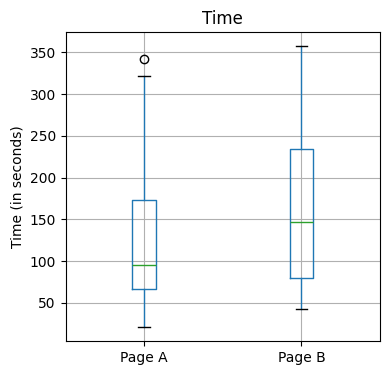

In [7]:
ax = session_times.boxplot(by='Page', column='Time',
                           figsize=(4, 4))
ax.set_xlabel('')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')

plt.tight_layout()
plt.show()

In [8]:
mean_a = session_times[session_times.Page == 'Page A'].Time.mean()
mean_b = session_times[session_times.Page == 'Page B'].Time.mean()
print(mean_b - mean_a)

35.66666666666667


The following code is different to the R version. idx_A and idx_B are reversed.

In [9]:
# Permutation test example with stickiness
def perm_fun(x, nA, nB):
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()

nA = session_times[session_times.Page == 'Page A'].shape[0]
nB = session_times[session_times.Page == 'Page B'].shape[0]
print(perm_fun(session_times.Time, nA, nB))

44.00952380952381


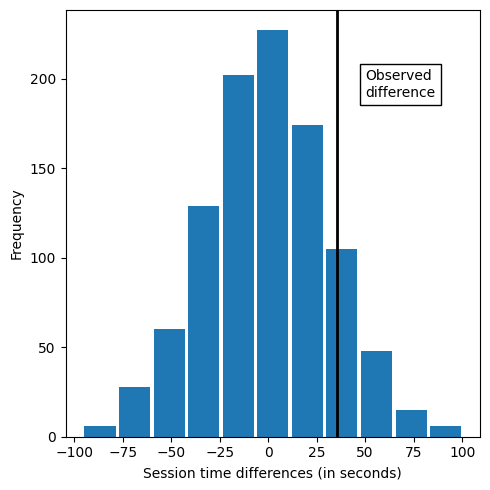

In [10]:
random.seed(1)
perm_diffs = [perm_fun(session_times.Time, nA, nB) for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x = mean_b - mean_a, color='black', lw=2)
ax.text(50, 190, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Session time differences (in seconds)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [11]:
# convert perm_diffs to numpy array to avoid problems with some Python installations
perm_diffs = np.array(perm_diffs)
print(np.mean(perm_diffs > mean_b - mean_a))

0.121


# Statistical Significance and P-Values

Observed difference: 0.0368%


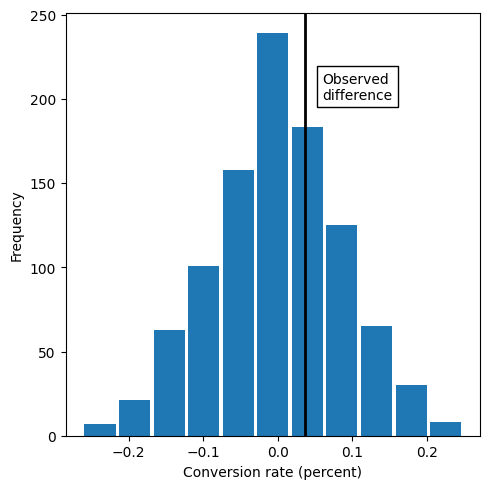

In [12]:
random.seed(1)
obs_pct_diff = 100 * (200 / 23739 - 182 / 22588)
print(f'Observed difference: {obs_pct_diff:.4f}%')
conversion = [0] * 45945
conversion.extend([1] * 382)
conversion = pd.Series(conversion)

perm_diffs = [100 * perm_fun(conversion, 23739, 22588)
              for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=obs_pct_diff, color='black', lw=2)
ax.text(0.06, 200, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Conversion rate (percent)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## P-Value
If `np.mean` is applied to a list of booleans, it gives the percentage of how often True was found in the list (#True / #Total).

In [13]:
print(np.mean([diff > obs_pct_diff for diff in perm_diffs]))

0.332


In [14]:
survivors = np.array([[200, 23739 - 200], [182, 22588 - 182]])
chi2, p_value, df, _ = stats.chi2_contingency(survivors)

print(f'p-value for single sided test: {p_value / 2:.4f}')

p-value for single sided test: 0.3498


# t-Tests

## Theoretical Deep-Dive: Two-Sample t-Test

Before computation power enabled practical permutation testing, parametric methods such as Student's $t$-test served as reference approximations for two-sample comparisons[cite: 131].
- **Test Statistic ($t$):** Standardizes the difference between group means by scaling it against the pooled standard error[cite: 130, 131].
- **Degrees of Freedom ($df$):** Adjusts the reference $t$-distribution shape based on sample sizes[cite: 130, 131].
- The resulting asymptotic $p$-value closely matches the empirical permutation $p$-value when sample distributions do not severely violate normality assumptions[cite: 131].

In [15]:
res = stats.ttest_ind(session_times[session_times.Page == 'Page A'].Time,
                      session_times[session_times.Page == 'Page B'].Time,
                      equal_var=False)
print(f'p-value for single sided test: {res.pvalue / 2:.4f}')

p-value for single sided test: 0.1408


In [16]:
tstat, pvalue, df = sm.stats.ttest_ind(
    session_times[session_times.Page == 'Page A'].Time,
    session_times[session_times.Page == 'Page B'].Time,
    usevar='unequal', alternative='smaller')
print(f'p-value: {pvalue:.4f}')

p-value: 0.1408


# ANOVA

## Theoretical Deep-Dive: ANOVA & The F-Statistic

When comparing three or more treatment groups (e.g., Pages 1, 2, 3, and 4), performing repeated pairwise $t$-tests causes **alpha inflation**—the cumulative probability of making at least one false positive (Type 1 error) escalates rapidly ($1 - (1 - \alpha)^k$)[cite: 132, 133, 139].

ANOVA solves this with an omnibus test using the **F-statistic**[cite: 138, 141]:
$$F = \frac{\text{Mean Square Between Groups (MS}_{\text{treatment}}\text{)}}{\text{Mean Square Error (MS}_{\text{residuals}}\text{)}}$$
- **Numerator:** Measures variability attributable to treatment differences across group means[cite: 141, 142].
- **Denominator:** Measures baseline within-group error / residual variability[cite: 141, 142].
- High $F$-values indicate that differences among group means exceed what random assignment produces[cite: 138, 141].

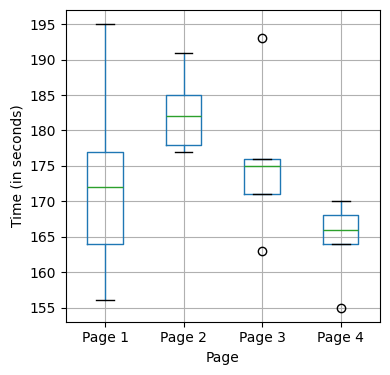

In [17]:
four_sessions = pd.read_csv(FOUR_SESSIONS_CSV)

ax = four_sessions.boxplot(by='Page', column='Time',
                           figsize=(4, 4))
ax.set_xlabel('Page')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')
plt.title('')

plt.tight_layout()
plt.show()

In [18]:
print(pd.read_csv(FOUR_SESSIONS_CSV).head())

     Page  Time
0  Page 1   164
1  Page 2   178
2  Page 3   175
3  Page 4   155
4  Page 1   172


**Interpretation of ANOVA Results:**
The ANOVA table produces an $F$-statistic of approximately 2.74 with an associated $p$-value of roughly 0.078[cite: 142]. At a conventional significance level of $\alpha = 0.05$, this result is not statistically significant[cite: 142]. This implies that the observed variance across the four web page stickiness means could plausibly occur purely by chance[cite: 141, 142].

In [19]:
observed_variance = four_sessions.groupby('Page').mean().var().iloc[0]
print('Observed means:', four_sessions.groupby('Page').mean().values.ravel())
print('Variance:', observed_variance)
# Permutation test example with stickiness
def perm_test(df):
    df = df.copy()
    df['Time'] = np.random.permutation(df['Time'].values)
    return df.groupby('Page').mean().var().iloc[0]

print(perm_test(four_sessions))

Observed means: [172.8 182.6 175.6 164.6]
Variance: 55.426666666666655
16.120000000000015


Pr(Prob) 0.08733333333333333


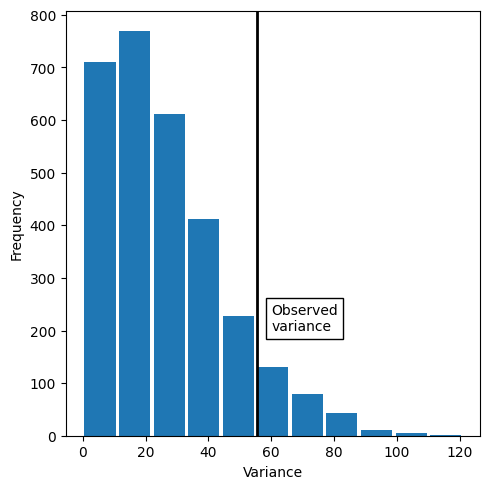

In [20]:
random.seed(1)
perm_variance = [perm_test(four_sessions) for _ in range(3000)]
print('Pr(Prob)', np.mean([var > observed_variance for var in perm_variance]))

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_variance, bins=11, rwidth=0.9)
ax.axvline(x = observed_variance, color='black', lw=2)
ax.text(60, 200, 'Observed\nvariance', bbox={'facecolor':'white'})
ax.set_xlabel('Variance')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## F-Statistic
We can compute an ANOVA table using statsmodel.

In [21]:
model = smf.ols('Time ~ Page', data=four_sessions).fit()

aov_table = sm.stats.anova_lm(model)
print(aov_table)

            df  sum_sq     mean_sq         F    PR(>F)
Page       3.0   831.4  277.133333  2.739825  0.077586
Residual  16.0  1618.4  101.150000       NaN       NaN


In [22]:
res = stats.f_oneway(four_sessions[four_sessions.Page == 'Page 1'].Time,
                     four_sessions[four_sessions.Page == 'Page 2'].Time,
                     four_sessions[four_sessions.Page == 'Page 3'].Time,
                     four_sessions[four_sessions.Page == 'Page 4'].Time)
print(f'F-Statistic: {res.statistic / 2:.4f}')
print(f'p-value: {res.pvalue / 2:.4f}')

F-Statistic: 1.3699
p-value: 0.0388


### Two-way anova only available with statsmodels
```
formula = 'len ~ C(supp) + C(dose) + C(supp):C(dose)'
model = ols(formula, data).fit()
aov_table = anova_lm(model, typ=2)
```

# Chi-Square Test
## Chi-Square Test: A Resampling Approach

## Theoretical Deep-Dive: Chi-Square Test of Independence

Used for categorical count data (such as web headline click-through contingency tables) to assess goodness-of-fit against expected null counts[cite: 143, 144].

### Pearson Residuals & Chi-Square Statistic ($\chi^2$)
$$R = \frac{\text{Observed} - \text{Expected}}{\sqrt{\text{Expected}}}, \quad \chi^2 = \sum_{i} \sum_{j} R^2$$
- **Degrees of Freedom:** For an $r \times c$ contingency table, $df = (r - 1) \times (c - 1)$[cite: 147].
- A high $\chi^2$ value indicates marked departure from the null hypothesis of independence across categories[cite: 143, 147].

In [23]:
# Table 3-4
click_rate = pd.read_csv(CLICK_RATE_CSV)
clicks = click_rate.pivot(index='Click', columns='Headline', values='Rate')
print(clicks)

Headline  Headline A  Headline B  Headline C
Click                                       
Click             14           8          12
No-click         986         992         988


In [24]:
# Table 3-5
row_average = clicks.mean(axis=1)
pd.DataFrame({
    'Headline A': row_average,
    'Headline B': row_average,
    'Headline C': row_average,
})

,Headline A,Headline B,Headline C
Click,,,
Click,11.333333,11.333333,11.333333
No-click,988.666667,988.666667,988.666667


In [25]:
# Resampling approach
box = [1] * 34
box.extend([0] * 2966)
random.shuffle(box)

def chi2(observed, expected):
    pearson_residuals = []
    for row, expect in zip(observed, expected):
        pearson_residuals.append([(observe - expect) ** 2 / expect
                                  for observe in row])
    # return sum of squares
    return np.sum(pearson_residuals)

expected_clicks = 34 / 3
expected_noclicks = 1000 - expected_clicks
expected = [expected_clicks, expected_noclicks]
chi2observed = chi2(clicks.values, expected)

def perm_fun(box):
    random.shuffle(box)
    sample_clicks = [sum(box[0:1000]),
                     sum(box[1000:2000]),
                     sum(box[2000:3000])]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [perm_fun(box) for _ in range(2000)]

resampled_p_value = sum(perm_chi2 > chi2observed) / len(perm_chi2)
print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')

Observed chi2: 1.6659
Resampled p-value: 0.4660


In [26]:
chisq, pvalue, df, expected = stats.chi2_contingency(clicks)
print(f'Observed chi2: {chisq:.4f}')
print(f'p-value: {pvalue:.4f}')

Observed chi2: 1.6659
p-value: 0.4348


The above algorithm uses sampling into the three sets without replacement. Alternatively, it is also possible to sample with replacement.

In [27]:
expected = [expected_clicks, expected_noclicks]
def sample_with_replacement(box):
    sample_clicks = [sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000))]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [sample_with_replacement(box) for _ in range(2000)]

resampled_p_value = sum(perm_chi2 > chi2observed) / len(perm_chi2)
print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')

Observed chi2: 1.6659
Resampled p-value: 0.4845


## Figure chi-sq distribution

## Theoretical Deep-Dive: Multi-Arm Bandits vs. Traditional A/B Testing

Traditional A/B testing allocates traffic evenly until the experiment concludes, exposing a substantial portion of visitors to suboptimal treatments throughout the trial[cite: 152, 154].

### Bandit Algorithms (e.g., Epsilon-Greedy)
- Balance **exploration** (pulling alternative treatments to collect more data) and **exploitation** (deploying the best-performing treatment discovered so far)[cite: 153].
- With probability $1 - \epsilon$, the current superior option is shown[cite: 153].
- With probability $\epsilon$, treatments are chosen at random[cite: 153].
- In web marketing and machine learning, multi-arm bandits minimize customer opportunity loss and converge more rapidly on optimal policies[cite: 151, 152, 154].

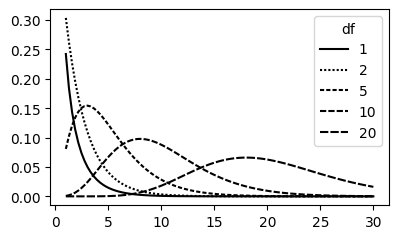

In [28]:
x = [1 + i * (30 - 1) / 99 for i in range(100)]

chi = pd.DataFrame({
    'x': x,
    'chi_1': stats.chi2.pdf(x, df=1),
    'chi_2': stats.chi2.pdf(x, df=2),
    'chi_5': stats.chi2.pdf(x, df=5),
    'chi_10': stats.chi2.pdf(x, df=10),
    'chi_20': stats.chi2.pdf(x, df=20),
})
fig, ax = plt.subplots(figsize=(4, 2.5))
ax.plot(chi.x, chi.chi_1, color='black', linestyle='-', label='1')
ax.plot(chi.x, chi.chi_2, color='black', linestyle=(0, (1, 1)), label='2')
ax.plot(chi.x, chi.chi_5, color='black', linestyle=(0, (2, 1)), label='5')
ax.plot(chi.x, chi.chi_10, color='black', linestyle=(0, (3, 1)), label='10')
ax.plot(chi.x, chi.chi_20, color='black', linestyle=(0, (4, 1)), label='20')
ax.legend(title='df')

plt.tight_layout()
plt.show()

## Fisher's Exact Test
Scipy has only an implementation of Fisher's Exact test for 2x2 matrices. There is a github repository that provides a Python implementation that uses the same code as the R version. Installing this requires a Fortran compiler.
```
stats.fisher_exact(clicks)
```

In [29]:
# stats.fisher_exact(clicks.values)

### Scientific Fraud

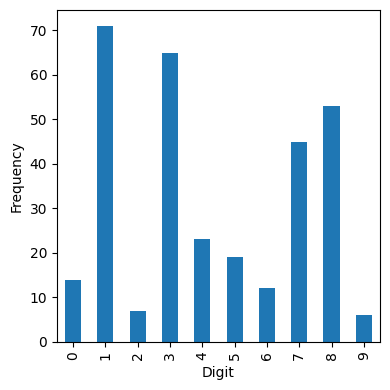

In [30]:
imanishi = pd.read_csv(IMANISHI_CSV)
imanishi.columns = [c.strip() for c in imanishi.columns]
ax = imanishi.plot.bar(x='Digit', y=['Frequency'], legend=False,
                      figsize=(4, 4))
ax.set_xlabel('Digit')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Power and Sample Size
statsmodels has a number of methods for power calculation

see e.g.: https://machinelearningmastery.com/statistical-power-and-power-analysis-in-python/

In [31]:
effect_size = sm.stats.proportion_effectsize(0.0121, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size,
                              alpha=0.05, power=0.8, alternative='larger')
print('Sample Size: %.3f' % result)

Sample Size: 116602.391


In [32]:
effect_size = sm.stats.proportion_effectsize(0.0165, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size,
                              alpha=0.05, power=0.8, alternative='larger')
print('Sample Size: %.3f' % result)

Sample Size: 5488.408
